# 06 - Dataset artifacts: quantifying their effect on the reported metrics

**Phase 6.** This notebook was added *after* the Phase-5 freeze, in response to external
review feedback asking that the study quantify - rather than merely note - how corpus
artifacts affect the headline numbers.

It is **strictly additive**. It reloads the same persisted split, rebuilds each model at
its frozen Phase-2 configuration, and writes only new files
(`results/artifact_impact.csv`, `results/near_duplicates.csv`,
`results/fig_artifact_impact.png`). Nothing written by notebooks 01-05 is modified, so
every number already reported in the dissertation remains valid and every existing
verification gate still passes.

Two artifacts are measured:

1. **HTML entity residue.** The corpus contains messages carrying raw HTML entities such as
   `&lt;#&gt;` (an anonymisation placeholder for a number). The cleaning pipeline lowercases,
   strips punctuation, then tokenizes - so `&lt;#&gt;` loses its `&`, `#` and `;` and survives
   as the single token **`ltgt`**. That token is an artifact of the corpus's construction, not
   a property of spam language, yet it is available to every classifier as a feature.
   **Question: how much of the reported performance depends on it?**

2. **Near-duplicate messages.** `load_dataset` drops *exact* duplicates before splitting, which
   removes the crudest form of train/test leakage. It does not remove messages that are nearly
   but not exactly identical. If a test message closely resembles a training message, a model
   can score on it by memorisation rather than generalisation.
   **Question: how much of the reported performance comes from test messages that have a close
   twin in training?**

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # precede numpy/xgboost import: avoids OpenMP deadlock

import sys, json, ast, re
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize

from src import config
from src.preprocessing import load_dataset, make_split, clean
from src.features import bow, tfidf_unigram, tfidf_ngram, lexical_pipeline
from src.models import get_models
from src.evaluation import metrics, get_scores

sns.set_theme(style="whitegrid")
RESULTS = config.RESULTS_DIR
np.random.seed(config.RANDOM_SEED)
print("Results dir:", RESULTS)

Results dir: /home/sdd/Documents/ovi/final year project/results


## 1. Rebuild the frozen configurations, and prove they are the frozen ones

The same guards as every other notebook: the row count must match what notebook 01 persisted,
and the split is reloaded rather than regenerated. Each model is rebuilt at its Phase-2 winning
representation with its Phase-2 winning hyperparameters, both read out of
`results/master_metrics.csv` rather than typed in.

The **anchor gate** below then refits each model on the unmodified text and asserts that it
reproduces its Phase-2 row to full floating-point precision. If this notebook could not
reproduce the frozen baseline, any difference it went on to measure would be uninterpretable -
it could be the artifact, or it could be drift. The gate rules out the second explanation
before the first is measured.

In [2]:
df = load_dataset()
eda = pd.read_csv(RESULTS / "eda_summary.csv").iloc[0]
assert len(df) == int(eda["rows_dedup"]), f"row count changed: {len(df)} != {int(eda['rows_dedup'])}"

assert config.SPLIT_PATH.exists(), "the persisted split is missing - do not re-split here"
saved = np.load(config.SPLIT_PATH)
train_idx, test_idx = saved["train_idx"], saved["test_idx"]

X_train, X_test, y_train, y_test = make_split(df)
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

mm = pd.read_csv(RESULTS / "master_metrics.csv")
best_rep = mm.loc[mm.groupby("model")["f1"].idxmax()].set_index("model")

MIN_DF = 2
VECTORIZERS = {
    "bow":           lambda: bow(min_df=MIN_DF),
    "tfidf_unigram": lambda: tfidf_unigram(min_df=MIN_DF),
    "tfidf_bigram":  lambda: tfidf_ngram(max_n=2, min_df=MIN_DF),
    "tfidf_trigram": lambda: tfidf_ngram(max_n=3, min_df=MIN_DF),
}
models_all = get_models(scale_pos_weight=scale_pos_weight)
MODEL_ORDER = ["MultinomialNB", "LogisticRegression", "LinearSVM", "XGBoost"]

def build(model_name):
    '''Rebuild one frozen configuration: its Phase-2 representation and best params.'''
    rep = best_rep.loc[model_name, "representation"]
    # best_params was written to CSV as a Python dict literal by notebook 02.
    # literal_eval, not eval: it parses literals only and cannot execute code.
    params = ast.literal_eval(best_rep.loc[model_name, "best_params"])
    est = clone(models_all[model_name][0]).set_params(**params)
    return Pipeline([("vec", lexical_pipeline(VECTORIZERS[rep]())), ("clf", est)]), rep, params

print(f"train={len(X_train)}  test={len(X_test)}  scale_pos_weight={scale_pos_weight:.3f}\n")
for name in MODEL_ORDER:
    _, rep, params = build(name)
    print(f"  {name:20s} {rep:14s} {params}")

train=4126  test=1032  scale_pos_weight=7.027

  MultinomialNB        bow            {'alpha': 1.0}
  LogisticRegression   tfidf_bigram   {'C': 10}
  LinearSVM            tfidf_unigram  {'C': 1}
  XGBoost              bow            {'learning_rate': 0.3, 'max_depth': 4, 'n_estimators': 200}


In [3]:
# --- ANCHOR GATE ---------------------------------------------------------------
# Refit every model on the UNMODIFIED text and require it to reproduce its Phase-2
# row exactly. This is the control arm for both experiments below.
ANCHOR_COLS = ["accuracy", "precision", "recall", "f1", "fpr", "auc", "tp", "fp", "tn", "fn"]

baseline = {}
for name in MODEL_ORDER:
    pipe, rep, _ = build(name)
    pipe.fit(X_train, y_train)
    m = metrics(y_test, pipe.predict(X_test), get_scores(pipe, X_test))
    baseline[name] = m
    expected = best_rep.loc[name]
    for col in ANCHOR_COLS:
        assert abs(float(m[col]) - float(expected[col])) < 1e-12, (
            f"ANCHOR FAILED for {name}.{col}: {m[col]} != {expected[col]}"
        )
    print(f"  [OK] {name:20s} reproduces Phase 2 exactly "
          f"(F1={m['f1']:.4f}  FPR={m['fpr']:.4f})")

print("\nANCHOR GATE PASSED - all 4 models reproduce their frozen Phase-2 metrics to 1e-12.")

  [OK] MultinomialNB        reproduces Phase 2 exactly (F1=0.9317  FPR=0.0055)


  [OK] LogisticRegression   reproduces Phase 2 exactly (F1=0.9444  FPR=0.0055)
  [OK] LinearSVM            reproduces Phase 2 exactly (F1=0.9482  FPR=0.0044)


  [OK] XGBoost              reproduces Phase 2 exactly (F1=0.9274  FPR=0.0055)

ANCHOR GATE PASSED - all 4 models reproduce their frozen Phase-2 metrics to 1e-12.


## 2. Artifact 1: the `ltgt` token

First establish the scale of the thing before measuring its effect. The token is counted the
way the pipeline actually produces it - by running the real `clean()` function and looking for
the literal token `ltgt` - not by pattern-matching HTML entities in the raw text. Those two
counts are different, and using the second in place of the first is an easy error to make.

In [4]:
cleaned_all = np.array([clean(t) for t in df["text"].values])
has_ltgt = np.array(["ltgt" in c.split() for c in cleaned_all])

split_of = np.empty(len(df), dtype=object)
split_of[train_idx] = "train"
split_of[test_idx] = "test"

prevalence = pd.DataFrame({
    "label": df["label"].values,
    "split": split_of,
    "has_ltgt": has_ltgt,
})

n_total = int(has_ltgt.sum())
print(f"messages containing the token 'ltgt': {n_total} of {len(df)} ({n_total/len(df)*100:.2f}%)\n")
print(prevalence[prevalence.has_ltgt].groupby(["split", "label"]).size()
      .rename("messages").reset_index()
      .replace({"label": {0: "ham", 1: "spam"}}).to_string(index=False))

# For contrast: how many messages carry ANY HTML entity in the raw text. This is a
# larger number and is NOT the same quantity - recorded here so the two are never confused.
n_any_entity = int(df["text"].str.contains(r"&[a-zA-Z]+;|&#\d+;", regex=True).sum())
print(f"\n(for contrast) messages carrying any raw HTML entity: {n_any_entity}")

messages containing the token 'ltgt': 197 of 5158 (3.82%)

split label  messages
 test   ham        47
train   ham       150

(for contrast) messages carrying any raw HTML entity: 270


### 2.1 Refit with the artifact removed

The entity residue is stripped from the **raw** text before the pipeline sees it, so the
cleaning, vectorising and fitting steps are otherwise identical to the frozen configuration.
Both arms use the same split, the same hyperparameters and the same random seed, so any
difference in the metrics is attributable to the artifact and nothing else.

Entities are replaced with a space rather than deleted, so that `word&lt;#&gt;word` does not
silently become a single fused token that never existed in either arm.

In [5]:
_ENTITY_RE = re.compile(r"&[a-zA-Z]+;|&#\d+;")

def strip_entities(text: str) -> str:
    '''Remove HTML entity residue, replacing each with a space (never fusing two words).'''
    return _ENTITY_RE.sub(" ", text)

X_train_s = np.array([strip_entities(t) for t in X_train])
X_test_s = np.array([strip_entities(t) for t in X_test])

n_changed_tr = int((X_train_s != X_train).sum())
n_changed_te = int((X_test_s != X_test).sum())
print(f"messages altered by stripping: train {n_changed_tr}, test {n_changed_te}")

# The token must be gone afterwards - otherwise the treatment did not do what it claims.
assert not any("ltgt" in clean(t).split() for t in X_train_s), "ltgt survived in train"
assert not any("ltgt" in clean(t).split() for t in X_test_s), "ltgt survived in test"
print("verified: the token 'ltgt' no longer occurs in either arm")

rows = []
for name in MODEL_ORDER:
    pipe, rep, _ = build(name)
    pipe.fit(X_train_s, y_train)
    m = metrics(y_test, pipe.predict(X_test_s), get_scores(pipe, X_test_s))
    b = baseline[name]
    rows.append({
        "experiment": "ltgt_removed",
        "model": name,
        "representation": rep,
        "f1_baseline": b["f1"], "f1_treatment": m["f1"], "f1_delta": m["f1"] - b["f1"],
        "fpr_baseline": b["fpr"], "fpr_treatment": m["fpr"], "fpr_delta": m["fpr"] - b["fpr"],
        "recall_baseline": b["recall"], "recall_treatment": m["recall"],
        "n_test": len(y_test),
        "spam_rate_baseline": float(y_test.mean()), "spam_rate_treatment": float(y_test.mean()),
    })
    print(f"  {name:20s} F1 {b['f1']:.4f} -> {m['f1']:.4f} ({m['f1']-b['f1']:+.4f})   "
          f"FPR {b['fpr']:.4f} -> {m['fpr']:.4f} ({m['fpr']-b['fpr']:+.4f})")

ltgt_impact = pd.DataFrame(rows)

messages altered by stripping: train 208, test 62


verified: the token 'ltgt' no longer occurs in either arm


  MultinomialNB        F1 0.9317 -> 0.9280 (-0.0037)   FPR 0.0055 -> 0.0066 (+0.0011)


  LogisticRegression   F1 0.9444 -> 0.9365 (-0.0079)   FPR 0.0055 -> 0.0066 (+0.0011)


  LinearSVM            F1 0.9482 -> 0.9407 (-0.0075)   FPR 0.0044 -> 0.0066 (+0.0022)


  XGBoost              F1 0.9274 -> 0.9120 (-0.0154)   FPR 0.0055 -> 0.0088 (+0.0033)


## 3. Artifact 2: near-duplicate messages

`load_dataset` drops exact duplicates before splitting. That removes the crudest leakage but
says nothing about messages that are nearly identical - the corpus contains many formulaic
messages ("Sorry, I'll call later", competition entry templates) that differ by a word or two.

Similarity is measured as **cosine similarity between binary bag-of-words vectors** of the
cleaned messages. A test message is called *near-duplicated* if its similarity to at least one
**training** message is at least 0.8. The direction matters: what threatens validity is a test
message resembling something the model was trained on, not two training messages resembling
each other.

Rather than refitting on a reduced corpus - which would change the training set size and
confound the comparison - the frozen models are evaluated on **two disjoint slices of the same
test set**: the messages that have a close training twin, and the messages that do not. If
performance on the clean slice is materially worse, part of the headline number is
memorisation.

**A caveat that must not be skipped when reading the output below.** Slicing the test set also
changes its class balance, because near-duplicates are disproportionately spam (formulaic
competition and prize-draw templates repeat; genuine personal messages do not). So the clean
slice has a *lower* spam rate than the full test set, and F1 falls mechanically when prevalence
falls, since precision is harder to sustain at a lower base rate even with an unchanged model.

F1 alone therefore overstates the effect. **Recall does not have this problem** - it is computed
only over the true spam messages and is independent of how many ham messages sit beside them.
Both are recorded, along with the spam rate of each slice, so the write-up can lead with the
prevalence-independent quantity instead of the flattering one.

In [6]:
SIM_THRESHOLD = 0.8

cv_bin = CountVectorizer(binary=True, min_df=1)
tr_clean = np.array([clean(t) for t in X_train])
te_clean = np.array([clean(t) for t in X_test])

M_tr = normalize(cv_bin.fit_transform(tr_clean))
M_te = normalize(cv_bin.transform(te_clean))

# 1,032 x 4,126 sparse product - small enough to compute in one shot.
sim = (M_te @ M_tr.T).toarray()
max_sim = sim.max(axis=1)
nearest = sim.argmax(axis=1)

is_near_dup = max_sim >= SIM_THRESHOLD
print(f"test messages with a training near-duplicate at cosine >= {SIM_THRESHOLD}: "
      f"{int(is_near_dup.sum())} of {len(y_test)} ({is_near_dup.mean()*100:.2f}%)")
print(f"  of those, spam: {int((is_near_dup & (y_test == 1)).sum())}, "
      f"ham: {int((is_near_dup & (y_test == 0)).sum())}")
print(f"  exact matches after cleaning (similarity 1.0): {int((max_sim >= 0.999).sum())}")

near_dup_examples = pd.DataFrame({
    "test_message": X_test[is_near_dup][:15],
    "nearest_training_message": X_train[nearest[is_near_dup]][:15],
    "cosine_similarity": max_sim[is_near_dup][:15],
    "label": np.where(y_test[is_near_dup][:15] == 1, "spam", "ham"),
})
near_dup_examples.to_csv(RESULTS / "near_duplicates.csv", index=False)
print(f"\nwrote {RESULTS / 'near_duplicates.csv'} ({len(near_dup_examples)} example pairs)")
near_dup_examples.head(5)

test messages with a training near-duplicate at cosine >= 0.8: 75 of 1032 (7.27%)
  of those, spam: 56, ham: 19
  exact matches after cleaning (similarity 1.0): 7

wrote /home/sdd/Documents/ovi/final year project/results/near_duplicates.csv (15 example pairs)


,test_message,nearest_training_message,cosine_similarity,label
0,This is the 2nd time we have tried to contact ...,This is the 2nd time we have tried 2 contact u...,0.826087,spam
1,"Dear Voucher Holder, To claim this weeks offer...","Dear Voucher Holder, To claim this weeks offer...",0.903696,spam
2,Someone U know has asked our dating service 2 ...,Someone U know has asked our dating service 2 ...,0.953463,spam
3,Had your contract mobile 11 Mnths? Latest Moto...,Had your contract mobile 11 Mnths? Latest Moto...,1.000000,spam
4,I'm not coming home 4 dinner.,I'm coming home 4 dinner.,0.894427,ham


In [7]:
# Evaluate the frozen models on the two disjoint test slices.
clean_mask = ~is_near_dup
dup_mask = is_near_dup

for name in MODEL_ORDER:
    pipe, rep, _ = build(name)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_sc = get_scores(pipe, X_test)

    m_all = metrics(y_test, y_pred, y_sc)
    m_clean = metrics(y_test[clean_mask], y_pred[clean_mask], y_sc[clean_mask])
    m_dup = metrics(y_test[dup_mask], y_pred[dup_mask], y_sc[dup_mask])

    rows.append({
        "experiment": "near_duplicate_slice",
        "model": name,
        "representation": rep,
        "f1_baseline": m_all["f1"], "f1_treatment": m_clean["f1"],
        "f1_delta": m_clean["f1"] - m_all["f1"],
        "fpr_baseline": m_all["fpr"], "fpr_treatment": m_clean["fpr"],
        "fpr_delta": m_clean["fpr"] - m_all["fpr"],
        "recall_baseline": m_all["recall"], "recall_treatment": m_clean["recall"],
        "n_test": int(clean_mask.sum()),
        "spam_rate_baseline": float(y_test.mean()),
        "spam_rate_treatment": float(y_test[clean_mask].mean()),
        "f1_near_dup_slice": m_dup["f1"],
        "n_near_dup": int(dup_mask.sum()),
        "recall_near_dup_slice": m_dup["recall"],
    })
    print(f"  {name:20s} recall {m_all['recall']:.4f} -> {m_clean['recall']:.4f} "
          f"({m_clean['recall']-m_all['recall']:+.4f})   "
          f"F1 {m_all['f1']:.4f} -> {m_clean['f1']:.4f}   "
          f"[near-dup slice n={int(dup_mask.sum())}: recall {m_dup['recall']:.4f}]")

print(f"\nspam rate: full test set {y_test.mean()*100:.2f}%  ->  "
      f"clean slice {y_test[clean_mask].mean()*100:.2f}%  "
      f"(near-dup slice {y_test[dup_mask].mean()*100:.2f}%)")
print("Recall is the prevalence-independent comparison; quote F1 only with the caveat above.")

artifact_impact = pd.DataFrame(rows)
artifact_impact.to_csv(RESULTS / "artifact_impact.csv", index=False)
print(f"\nwrote {RESULTS / 'artifact_impact.csv'} ({len(artifact_impact)} rows)")
artifact_impact

  MultinomialNB        recall 0.9062 -> 0.8333 (-0.0729)   F1 0.9317 -> 0.8824   [near-dup slice n=75: recall 1.0000]


  LogisticRegression   recall 0.9297 -> 0.8750 (-0.0547)   F1 0.9444 -> 0.9065   [near-dup slice n=75: recall 1.0000]


  LinearSVM            recall 0.9297 -> 0.8750 (-0.0547)   F1 0.9482 -> 0.9130   [near-dup slice n=75: recall 1.0000]


  XGBoost              recall 0.8984 -> 0.8194 (-0.0790)   F1 0.9274 -> 0.8741   [near-dup slice n=75: recall 1.0000]

spam rate: full test set 12.40%  ->  clean slice 7.52%  (near-dup slice 74.67%)
Recall is the prevalence-independent comparison; quote F1 only with the caveat above.

wrote /home/sdd/Documents/ovi/final year project/results/artifact_impact.csv (8 rows)


,experiment,model,representation,f1_baseline,f1_treatment,f1_delta,fpr_baseline,fpr_treatment,fpr_delta,recall_baseline,recall_treatment,n_test,spam_rate_baseline,spam_rate_treatment,f1_near_dup_slice,n_near_dup,recall_near_dup_slice
0,ltgt_removed,MultinomialNB,bow,0.931727,0.928000,-0.003727,0.005531,0.006637,0.001106,0.906250,0.906250,1032,0.124031,0.124031,NaN,NaN,NaN
1,ltgt_removed,LogisticRegression,tfidf_bigram,0.944444,0.936508,-0.007937,0.005531,0.006637,0.001106,0.929688,0.921875,1032,0.124031,0.124031,NaN,NaN,NaN
2,ltgt_removed,LinearSVM,tfidf_unigram,0.948207,0.940711,-0.007496,0.004425,0.006637,0.002212,0.929688,0.929688,1032,0.124031,0.124031,NaN,NaN,NaN
3,ltgt_removed,XGBoost,bow,0.927419,0.912000,-0.015419,0.005531,0.008850,0.003319,0.898438,0.890625,1032,0.124031,0.124031,NaN,NaN,NaN
4,near_duplicate_slice,MultinomialNB,bow,0.931727,0.882353,-0.049374,0.005531,0.004520,-0.001011,0.906250,0.833333,957,0.124031,0.075235,0.99115,75.0,1.0
5,near_duplicate_slice,LogisticRegression,tfidf_bigram,0.944444,0.906475,-0.037970,0.005531,0.004520,-0.001011,0.929688,0.875000,957,0.124031,0.075235,0.99115,75.0,1.0
6,near_duplicate_slice,LinearSVM,tfidf_unigram,0.948207,0.913043,-0.035164,0.004425,0.003390,-0.001035,0.929688,0.875000,957,0.124031,0.075235,0.99115,75.0,1.0
7,near_duplicate_slice,XGBoost,bow,0.927419,0.874074,-0.053345,0.005531,0.004520,-0.001011,0.898438,0.819444,957,0.124031,0.075235,0.99115,75.0,1.0


## 4. Figure

Two panels, one per artifact. The left panel shows F1 with and without the `ltgt` token; the
right shows F1 on the full test set against F1 on the near-duplicate-free slice. Both are
plotted on a common axis so the two effects can be compared by eye rather than by adjective.

wrote /home/sdd/Documents/ovi/final year project/results/fig_artifact_impact.png


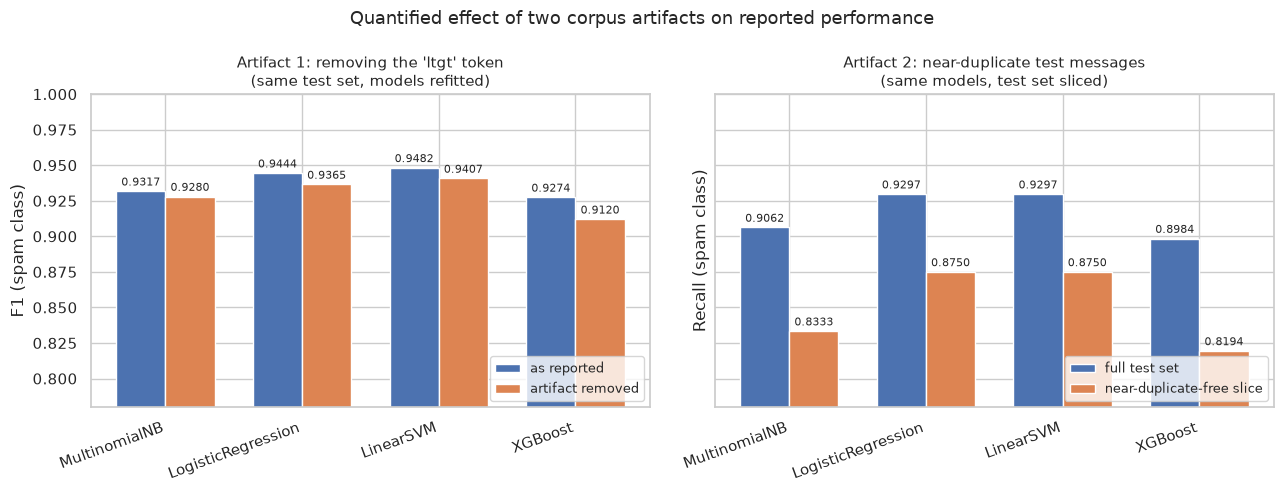

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left panel uses F1 (both arms share the identical test set, so F1 is comparable).
# Right panel uses RECALL, not F1: the two slices have different spam rates, and only
# recall is independent of class balance. Plotting F1 there would exaggerate the effect.
for ax, exp, metric, title, ylab, lab_b, lab_t in [
    (axes[0], "ltgt_removed", "f1",
     "Artifact 1: removing the 'ltgt' token\n(same test set, models refitted)",
     "F1 (spam class)", "as reported", "artifact removed"),
    (axes[1], "near_duplicate_slice", "recall",
     "Artifact 2: near-duplicate test messages\n(same models, test set sliced)",
     "Recall (spam class)", "full test set", "near-duplicate-free slice"),
]:
    sub = artifact_impact[artifact_impact.experiment == exp].set_index("model").loc[MODEL_ORDER]
    b_vals, t_vals = sub[f"{metric}_baseline"], sub[f"{metric}_treatment"]
    x = np.arange(len(MODEL_ORDER))
    w = 0.36
    ax.bar(x - w/2, b_vals, w, label=lab_b, color="#4C72B0")
    ax.bar(x + w/2, t_vals, w, label=lab_t, color="#DD8452")
    for xi, (b, t) in enumerate(zip(b_vals, t_vals)):
        ax.text(xi - w/2, b + 0.004, f"{b:.4f}", ha="center", fontsize=8)
        ax.text(xi + w/2, t + 0.004, f"{t:.4f}", ha="center", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=20, ha="right")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylab)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_ylim(0.78, 1.0)
fig.suptitle("Quantified effect of two corpus artifacts on reported performance", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS / "fig_artifact_impact.png", dpi=150, bbox_inches="tight")
print(f"wrote {RESULTS / 'fig_artifact_impact.png'}")
plt.show()

## 5. What this notebook establishes

The numbers printed above are written to `results/artifact_impact.csv` and are the only source
the dissertation quotes for this analysis. Nothing here is hand-typed into the report.

Both experiments are **controlled**: the anchor gate in section 1 proves the baseline arm
reproduces the frozen Phase-2 metrics exactly, so the deltas isolate the artifact rather than
any incidental drift.

Note the asymmetry between the two experiments. Removing the `ltgt` token is a *counterfactual
refit* - the models are retrained without it, and the delta says what the study would have
reported had the corpus never carried the artifact. The near-duplicate analysis is a *slice of
the same predictions* - no refitting, so it says what the reported number would look like had
the test set excluded messages that closely resemble training material. The second is the more
pessimistic reading, because a real deployment sees genuinely novel messages.